# Part I. Aggregate Data and Plot Survival Rate and Hazard Rate




In [1]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

In [2]:
# Load the data
education = pd.read_csv("educational_service_long.csv")

education

,custid,startlen,time,payleft,lagtest,cancelnow
0,137,6,1,5,4,0
1,137,6,2,4,4,0
2,137,6,3,3,4,0
3,137,6,4,2,4,0
4,137,6,5,1,4,0
...,...,...,...,...,...,...
43437,11392,6,9,3,4,0
43438,11392,6,10,2,4,0
43439,11392,6,11,1,4,0
43440,11786,6,1,5,0,0


## Aggregate Data

In [3]:
# Aggregate data for plotting hazard and survival functions
education_agg = education.groupby(['startlen', 'time']).agg(
    defect=('cancelnow', 'sum'),
    n=('custid', 'count')
).reset_index()
education_agg

,startlen,time,defect,n
0,1,1,20,2256
1,1,2,76,2236
2,1,3,157,2160
3,1,4,108,2003
4,1,5,128,1895
5,1,6,138,1767
6,1,7,130,1629
7,1,8,99,1499
8,1,9,64,1400
9,1,10,58,1336


## Calculate hazardrate and survival rate

In [4]:
education_agg['cumdefect'] = education_agg.groupby('startlen')['defect'].cumsum()
education_agg['initialn'] = education_agg.groupby('startlen')['n'].transform('max')
education_agg['hazardrate'] = education_agg['defect'] / education_agg['n']
education_agg['survivalrate'] = (education_agg['initialn'] - education_agg['cumdefect']) / education_agg['initialn']
education_agg

,startlen,time,defect,n,cumdefect,initialn,hazardrate,survivalrate
0,1,1,20,2256,20,2256,0.008865,0.991135
1,1,2,76,2236,96,2256,0.033989,0.957447
2,1,3,157,2160,253,2256,0.072685,0.887855
3,1,4,108,2003,361,2256,0.053919,0.839982
4,1,5,128,1895,489,2256,0.067546,0.783245
5,1,6,138,1767,627,2256,0.078098,0.722074
6,1,7,130,1629,757,2256,0.079804,0.664450
7,1,8,99,1499,856,2256,0.066044,0.620567
8,1,9,64,1400,920,2256,0.045714,0.592199
9,1,10,58,1336,978,2256,0.043413,0.566489


## Plot Survival rate and hazard rate

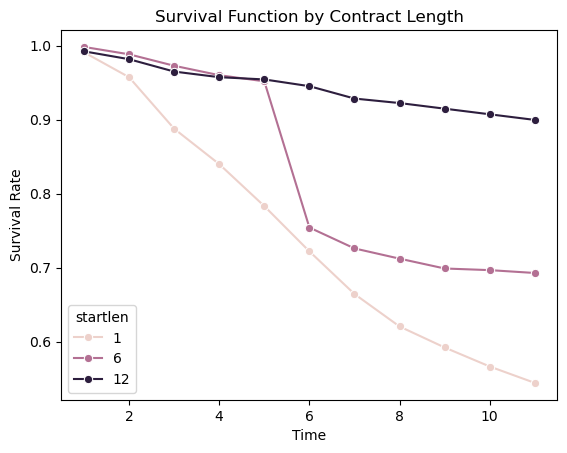

In [5]:
# Plot survival function
sns.lineplot(data=education_agg, x='time', y='survivalrate', hue='startlen', marker='o')
plt.title('Survival Function by Contract Length')
plt.xlabel('Time')
plt.ylabel('Survival Rate')
plt.show()

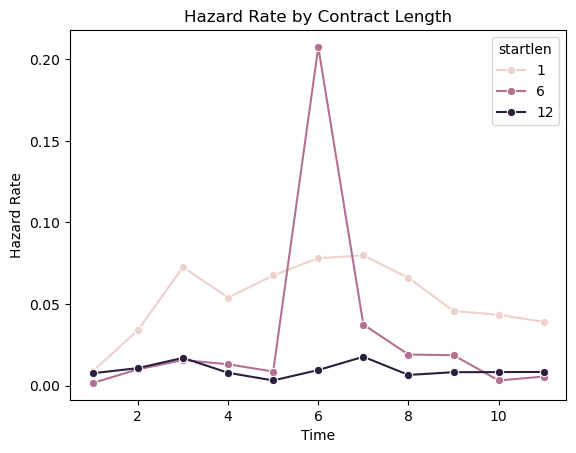

In [6]:
# Plot hazard rate function
sns.lineplot(data=education_agg, x='time', y='hazardrate', hue='startlen', marker='o')
plt.title('Hazard Rate by Contract Length')
plt.xlabel('Time')
plt.ylabel('Hazard Rate')
plt.show()


# Part II. Model: Logistic Regression

### lagtest_prevmonth:whether a customer submitted at least one exercise in the previous month (1) or not (0)

In [7]:
education["lagtest_prevmonth"] = (education["lagtest"] > 0).astype(int)

### cumlagtest: the cumulative sum of the lagtest column for each customer (custid).

In [8]:
education['cumlagtest'] = education.groupby('custid')['lagtest'].cumsum()

### contractup: to signal whether the customer’s contract has ended.

In [9]:
education['contractup'] = np.where(education['payleft'] == 0, 1, 0)

#  Logistic regression

In [10]:
# Logistic regression model discreate time
mod = smf.logit(
    'cancelnow ~ C(time) + lagtest_prevmonth + cumlagtest + payleft + contractup + C(startlen)',
    data=education
).fit()

# Display the summary of the model
print(mod.summary())


Optimization terminated successfully.
         Current function value: 0.113036
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:              cancelnow   No. Observations:                43442
Model:                          Logit   Df Residuals:                    43425
Method:                           MLE   Df Model:                           16
Date:                Thu, 27 Mar 2025   Pseudo R-squ.:                  0.2997
Time:                        15:31:01   Log-Likelihood:                -4910.5
converged:                       True   LL-Null:                       -7011.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -6.7142      0.271    -24.731      0.000      -7.246      -6.182
C(time)

In [11]:
# Predict hazard rates
education['hazardrate_pred'] = mod.predict(education)

education

,custid,startlen,time,payleft,lagtest,cancelnow,lagtest_prevmonth,cumlagtest,contractup,hazardrate_pred
0,137,6,1,5,4,0,1,4,0,0.000655
1,137,6,2,4,4,0,1,8,0,0.001579
2,137,6,3,3,4,0,1,12,0,0.002446
3,137,6,4,2,4,0,1,16,0,0.001146
4,137,6,5,1,4,0,1,20,0,0.000952
...,...,...,...,...,...,...,...,...,...,...
43437,11392,6,9,3,4,0,1,36,0,0.001046
43438,11392,6,10,2,4,0,1,40,0,0.000690
43439,11392,6,11,1,4,0,1,44,0,0.000485
43440,11786,6,1,5,0,0,0,0,0,0.014869


In [12]:
# Aggregate predicted hazard rates for plotting
education_pred = education.groupby(['startlen', 'time']).agg(
    hazardrate_pred=('hazardrate_pred', 'mean')
).reset_index()
education_pred

,startlen,time,hazardrate_pred
0,1,1,0.008899
1,1,2,0.034296
2,1,3,0.070301
3,1,4,0.053840
4,1,5,0.062120
5,1,6,0.082747
6,1,7,0.084915
7,1,8,0.063718
8,1,9,0.050546
9,1,10,0.039735


In [13]:
education_agg = pd.merge(education_agg, education_pred, on=['startlen', 'time'])


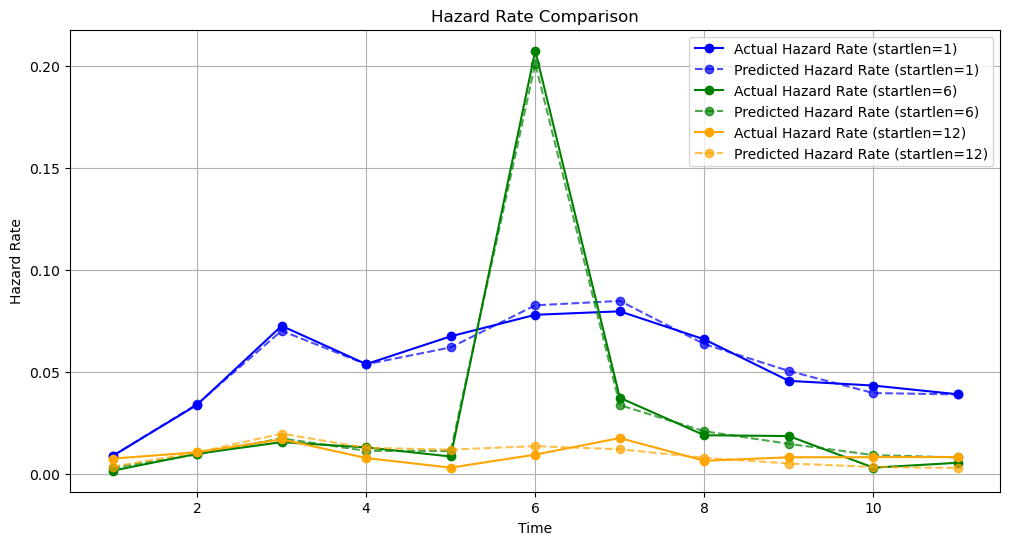

In [14]:
# Define colors for better visibility
colors = {1: 'blue', 6: 'green', 12: 'orange'}

# Create the plot
plt.figure(figsize=(12, 6))

for startlen in [1, 6, 12]:
    subset = education_agg[education_agg['startlen'] == startlen]

    # Plot actual hazard rate
    plt.plot(subset['time'], subset['hazardrate'], 'o-',
             label=f"Actual Hazard Rate (startlen={startlen})",
             color=colors[startlen])

    # Plot predicted hazard rate
    plt.plot(subset['time'], subset['hazardrate_pred'], 'o--',
             label=f"Predicted Hazard Rate (startlen={startlen})",
             color=colors[startlen], alpha=0.7)  # Make predicted rate slightly transparent

# Customize plot
plt.title("Hazard Rate Comparison")
plt.xlabel("Time")
plt.ylabel("Hazard Rate")
plt.legend()
plt.grid(True)  # Add grid for better readability
plt.show()



In [15]:
# Initialize a new column for model-based survival function
education_agg['survival_rate_pred'] = 1.0

# Compute survival function iteratively for each 'startlen' group
for start in education_agg['startlen'].unique():
    sub_df = education_agg[education_agg['startlen'] == start].copy()

    # First survival rate
    sub_df.loc[sub_df.index[0], 'survival_rate_pred'] = 1 - sub_df.iloc[0]['hazardrate_pred']

    # Compute recursively for subsequent time periods
    for i in range(1, len(sub_df)):
        sub_df.loc[sub_df.index[i], 'survival_rate_pred'] = (
            sub_df.loc[sub_df.index[i - 1], 'survival_rate_pred'] *
            (1 - sub_df.loc[sub_df.index[i], 'hazardrate_pred'])
        )

    # Assign back to the main dataframe
    education_agg.loc[education_agg['startlen'] == start, 'survival_rate_pred'] = sub_df['survival_rate_pred']

In [16]:
education_agg

,startlen,time,defect,n,cumdefect,initialn,hazardrate,survivalrate,hazardrate_pred,survival_rate_pred
0,1,1,20,2256,20,2256,0.008865,0.991135,0.008899,0.991101
1,1,2,76,2236,96,2256,0.033989,0.957447,0.034296,0.957111
2,1,3,157,2160,253,2256,0.072685,0.887855,0.070301,0.889825
3,1,4,108,2003,361,2256,0.053919,0.839982,0.053840,0.841916
4,1,5,128,1895,489,2256,0.067546,0.783245,0.062120,0.789617
5,1,6,138,1767,627,2256,0.078098,0.722074,0.082747,0.724278
6,1,7,130,1629,757,2256,0.079804,0.664450,0.084915,0.662776
7,1,8,99,1499,856,2256,0.066044,0.620567,0.063718,0.620545
8,1,9,64,1400,920,2256,0.045714,0.592199,0.050546,0.589179
9,1,10,58,1336,978,2256,0.043413,0.566489,0.039735,0.565768


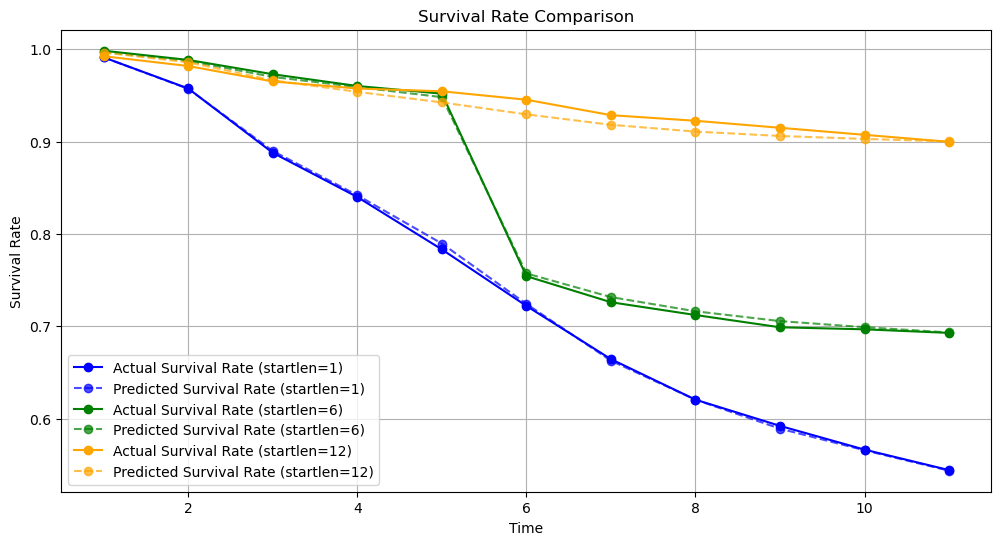

In [17]:
# Create the plot
plt.figure(figsize=(12, 6))

for startlen in [1, 6, 12]:
    subset = education_agg[education_agg['startlen'] == startlen]

    # Plot actual survival rate
    plt.plot(subset['time'], subset['survivalrate'], 'o-',
             label=f"Actual Survival Rate (startlen={startlen})",
             color=colors[startlen])

    # Plot predicted survival rate
    plt.plot(subset['time'], subset['survival_rate_pred'], 'o--',
             label=f"Predicted Survival Rate (startlen={startlen})",
             color=colors[startlen], alpha=0.7)  # Slight transparency for better differentiation

# Customize plot
plt.title("Survival Rate Comparison")
plt.xlabel("Time")
plt.ylabel("Survival Rate")
plt.legend()
plt.grid(True)  # Add grid for better readability
plt.show()


ROC AUC: 0.896899192309923


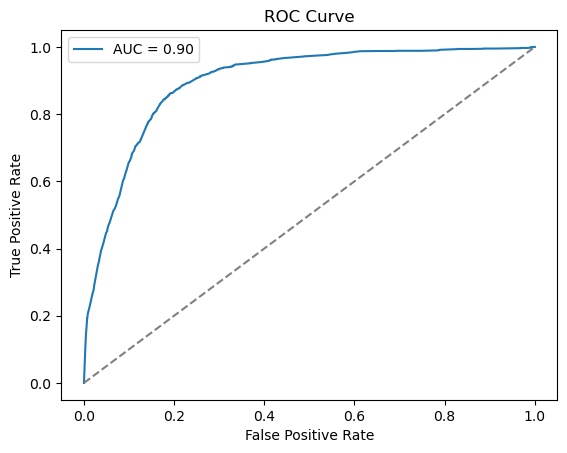

In [18]:
# Evaluate predictions
roc_auc = roc_auc_score(education['cancelnow'], education['hazardrate_pred'])
print(f"ROC AUC: {roc_auc}")

fpr, tpr, thresholds = roc_curve(education['cancelnow'], education['hazardrate_pred'])
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [19]:
# Find the optimal threshold using the ROC curve
# The threshold is chosen to minimize the sume of Type I error and Type II error, which is equivalent to min fpr + (1-tpr)
optimal_idx = np.argmin(fpr + (1 - tpr))
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold: {optimal_threshold}")

Optimal Threshold: 0.04326847533116066


In [20]:
# Confusion matrix using optimal threshold
education['cancelnow_pred'] = (education['hazardrate_pred'] >= optimal_threshold).astype(int)
cm = confusion_matrix(education['cancelnow'], education['cancelnow_pred'])
cm

array([[33807,  7986],
       [  228,  1421]])

In [21]:
# Convert to DataFrame for readability
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])
cm_df

,Predicted 0,Predicted 1
Actual 0,33807,7986
Actual 1,228,1421


In [22]:
accuracy = cm.diagonal().sum() / cm.sum()
print(f"Accuracy: {accuracy}")

Accuracy: 0.8109203075364855
